# Setup forcing for the case studies

In [2]:
import cmocean
import cftime
from copy import copy
import datetime
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr


%load_ext autoreload
%autoreload 2
# %matplotlib notebook

In [3]:
mission_id = 32

In [4]:
ds = xr.load_dataset('../data/FRF-ocean_waves_8m-array_202110.nc')
mission = xr.load_dataset(f'../../data/swift/doi_10_5061_dryad_hx3ffbgk0__v20230321/mission_{mission_id}.nc')
waves = ds.sel(time=mission.time.mean(), method='nearest')

In [5]:
waves

<xarray.Dataset> Size: 20kB
Dimensions:                         (waveFrequency: 62, waveDirectionBins: 72)
Coordinates:
    time                            datetime64[ns] 8B 2021-10-13T17:00:00.000...
  * waveFrequency                   (waveFrequency) float32 248B 0.04 ... 0.4975
  * waveDirectionBins               (waveDirectionBins) float32 288B 0.0 ... ...
Data variables: (12/28)
    station_name                    |S12 12B b'8m-Array'
    latitude                        float64 8B 36.19
    longitude                       float64 8B 75.74
    nominalDepth                    float32 4B 8.0
    depth                           float32 4B 9.685
    gaugeDepth                      float32 4B nan
    ...                              ...
    waveA1Value                     (waveFrequency) float32 248B -0.09914 ......
    waveB1Value                     (waveFrequency) float32 248B -0.06682 ......
    waveA2Value                     (waveFrequency) float32 248B -0.003242 .....
    waveB2Value                     (waveFrequency) float32 248B -0.06563 ......
    waterLevel                      float32 4B 0.6147
    airPressure                     float32 4B 1.016e+03
Attributes: (12/57)
    featureType:                     timeSeries
    title:                           FRF 8m Array
    summary:                         USACE Coastal Observation and Analysis B...
    history:                         1991-01-01:dataset created
    source:                          In situ observations from FRF-ocean_wave...
    sourceUrl:                       (local files)
    ...                              ...
    cross_shore_angle_units:         degrees
    cross_shore_angle_description:   cross shore angle at the USACE FRF site ...
    cross_shore_angle:               71.8
    date_created:                    2021-10-31
    date_issued:                     2021-10-31
    time_coverage_end:               2021-10-31T23:00:00

In [6]:
mission_df_8m = pd.read_csv('../data/mission_df.csv')
mission_df_8m[(mission_df_8m['mission number'] == 19) | 
              (mission_df_8m['mission number'] == 32) | 
              (mission_df_8m['mission number'] == 56)]

,Unnamed: 0,time,mission number,Hs [m] (8marray),Tm [s] (8marray),Mean Dir [deg] (8marray),Mean Dir FRF [deg] (8marray),Mean Dir FRF Math conv (8marray),Mean Wavelength [m] (8marray),wind speed [m/s],wind direction [deg],wind direction FRF [deg],wind direction FRF math convention [deg],water level [m],stokes drift [m/s] (8marray),surf zone width [m],breaking iribarren,surf zone edge [m]
6,6,2021-10-08 18:31:59.996640,19,1.180221,7.930591,67.856860,48.856857,221.143143,64.210673,8.237333,33.152010,14.152012,255.847988,-0.399,0.070684,202.765841,0.184098,277.765841
21,21,2021-10-25 17:33:29.996040,56,0.610194,6.833234,100.507706,81.507706,188.492294,53.583811,3.360000,188.820720,169.820724,100.179276,0.123,0.029537,129.555901,0.340890,204.555901
39,39,2021-10-13 17:25:29.998680,32,1.087330,7.631857,58.450040,39.450039,230.549961,61.345759,6.483833,4.238652,-14.761348,284.761348,0.781,0.067320,187.884512,0.270100,262.884512


In [7]:
mission_df_8m['wind direction [deg]'] - mission_df_8m['wind direction FRF [deg]']

0     19.000004
1     19.000000
2     19.000000
3     19.000000
4     18.999998
        ...    
62    18.999998
63    19.000000
64    18.999996
65    19.000004
66    19.000005
Length: 67, dtype: float64

In [8]:
wind_spd = mission_df_8m.loc[mission_df_8m['mission number'] == mission_id]['wind speed [m/s]'].values[0]
wind_dir = mission_df_8m.loc[mission_df_8m['mission number'] == mission_id]['wind direction [deg]'].values[0]

print(f'Wind Speed for Mission {mission_id}: {wind_spd:.2f} m/s')
FRF_OFFSET = 90 - waves.cross_shore_angle
print(f'Wind Direction for Mission {mission_id}: {(wind_dir - FRF_OFFSET +360)%360:.2f} deg')

Wind Speed for Mission 32: 6.48 m/s
Wind Direction for Mission 32: 346.04 deg


/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_17822/2104366305.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  my_cmap = copy(plt.cm.get_cmap('inferno'))


Text(0.5, 1.0, '2021-10-13 17:25\n N/E CW')

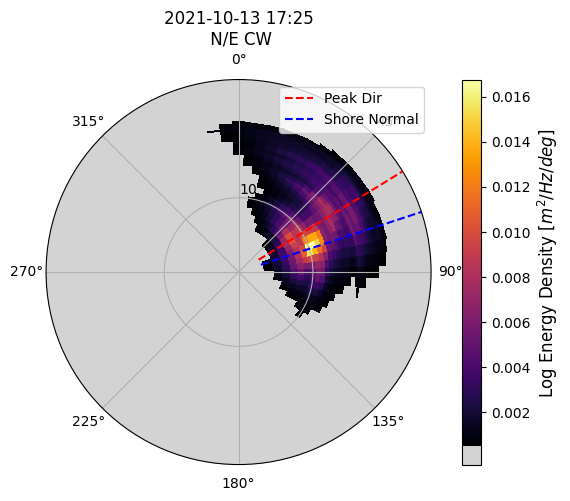

In [9]:
# Plot a single directional spectra
FRF_OFFSET = 0
dirs = (waves.waveDirectionBins - FRF_OFFSET + 360) % 360
dir_sort = dirs.argsort()
dirs = dirs.values[dir_sort]
freqs = waves.waveFrequency 
spectra = waves.waveEnergyDensity
dir_spectra = waves.directionalWaveEnergyDensity
dir_spectra = dir_spectra.values[:, dir_sort]

theta, r = np.meshgrid(np.radians(dirs), freqs)

my_cmap = copy(plt.cm.get_cmap('inferno'))
my_cmap.set_under('lightgrey')

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8,5))
ax.set_theta_direction(-1)
ax.set_theta_zero_location("N")
ax.vlines((mission_df_8m.loc[mission_df_8m['mission number'] == mission_id]['Mean Dir [deg] (8marray)'] - FRF_OFFSET) * (np.pi/180), 0.05, 0.5, zorder=3, color='r', linestyle='dashed', label='Peak Dir')
ax.vlines((waves.cross_shore_angle - FRF_OFFSET) * (np.pi/180), 0.05, 0.5, zorder=3, color='b', linestyle='dashed', label='Shore Normal')

im = ax.pcolormesh(theta, r, dir_spectra, cmap=my_cmap, vmin=5e-04)
# im = ax.pcolormesh(theta, r, np.log10(dir_spectra), cmap=my_cmap, vmin=np.log10(5e-04))
cbar = fig.colorbar(im, extend='min', extendrect=True)
cbar.set_label('Log Energy Density [$m^2/Hz/deg$]', rotation=90, fontsize=12)
ax.legend()
ax.set_rscale('log')
ax.set_rlabel_position(0)
ax.set_title(
    # f'Mission {mission_id}\n
    f'{mission_df_8m[(mission_df_8m['mission number'] == mission_id)]['time'].item()[:16]}\n N/E CW')

In [10]:
mission_df_8m.loc[mission_df_8m['mission number'] == mission_id]['Mean Dir [deg] (8marray)'] - FRF_OFFSET

39    58.45004
Name: Mean Dir [deg] (8marray), dtype: float64

39    76.65004
Name: Mean Dir [deg] (8marray), dtype: float64


/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_11412/2678353569.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  my_cmap = copy(plt.cm.get_cmap('inferno'))


Text(0.5, 1.0, 'Mission 32\n2021-10-13 17:25\nNE CW')

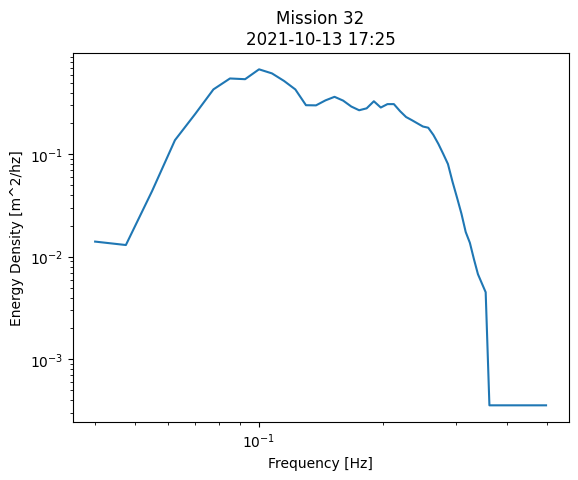

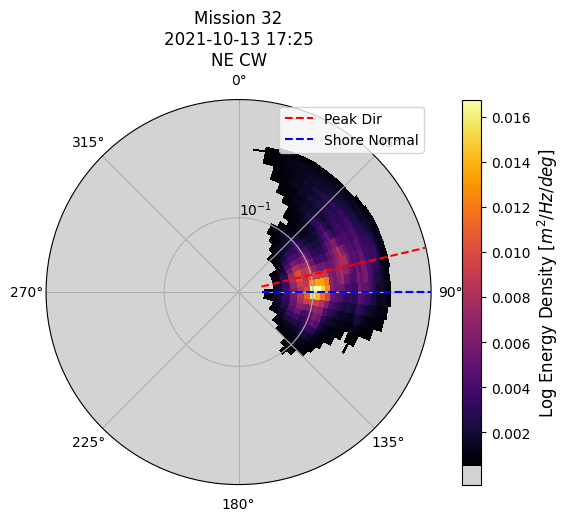

In [45]:
# Plot a single directional spectra
FRF_OFFSET = -(90 - waves.cross_shore_angle)
dirs = (waves.waveDirectionBins - FRF_OFFSET + 360) % 360
dir_sort = dirs.argsort()
dirs = dirs.values[dir_sort]
freqs = waves.waveFrequency 
spectra = waves.waveEnergyDensity
dir_spectra = waves.directionalWaveEnergyDensity
dir_spectra = dir_spectra.values[:, dir_sort]

theta, r = np.meshgrid(np.radians(dirs), freqs)

my_cmap = copy(plt.cm.get_cmap('inferno'))
my_cmap.set_under('lightgrey')

# Plot the 1d spectra
fig, ax = plt.subplots()
ax.loglog(freqs, spectra)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Energy Density [m^2/hz]')
ax.set_title(
    f'Mission {mission_id}\n{mission_df_8m[(mission_df_8m['mission number'] == mission_id)]['time'].item()[:16]}')
# plot directional spectra
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8,5))
ax.set_theta_direction('clockwise')
ax.set_theta_zero_location("N")

ax.vlines((mission_df_8m.loc[mission_df_8m['mission number'] == mission_id]['Mean Dir [deg] (8marray)'] - FRF_OFFSET) * (np.pi/180), 0.05, 0.5, zorder=3, color='r', linestyle='dashed', label='Peak Dir')
print(mission_df_8m.loc[mission_df_8m['mission number'] == mission_id]['Mean Dir [deg] (8marray)'] - FRF_OFFSET)
ax.vlines((waves.cross_shore_angle - FRF_OFFSET) * (np.pi/180), 0.05, 0.5, zorder=3, color='b', linestyle='dashed', label='Shore Normal')
im = ax.pcolormesh(theta, r, dir_spectra, cmap=my_cmap, vmin=5e-04)
# im = ax.pcolormesh(theta, r, np.log10(dir_spectra), cmap=my_cmap, vmin=np.log10(5e-04))
cbar = fig.colorbar(im, extend='min', extendrect=True)
cbar.set_label('Log Energy Density [$m^2/Hz/deg$]', rotation=90, fontsize=12)
ax.legend()
ax.set_rscale('log')
ax.set_rlabel_position(0)
ax.set_title(
    f'Mission {mission_id}\n{mission_df_8m[(mission_df_8m['mission number'] == mission_id)]['time'].item()[:16]}\nNE CW')

In [25]:
mission_df_8m.loc[mission_df_8m['mission number'] == mission_id]['Mean Dir [deg] (8marray)'] - FRF_OFFSET

39    76.65004
Name: Mean Dir [deg] (8marray), dtype: float64

Write this spectrum to a swan spectrum file for forcing. The function below was found at this link (https://github.com/caiostringari/swantools/blob/master/swantools/io/SwanIO.py) and has been modfied.

In [46]:
from swan_spectral_wave_forcing import write_stationary_spec2d
# Save the 2d forcing spectra
fname = f'./mission{mission_id}.spc2d'
factor = 10**-6
write_stationary_spec2d(fname,freqs.values,dirs,dir_spectra, factor)